In [1]:
import xgboost, dask, distributed, sys

print("xgboost:", xgboost.__version__)
print("dask:", dask.__version__)
print("distributed:", distributed.__version__)
print("python:", sys.version)

xgboost: 2.1.4
dask: 2024.12.1
distributed: 2024.12.1
python: 3.11.12 (main, Apr  9 2025, 08:55:55) [GCC 13.3.0]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from newutils.data.datasets import load_train_subset, add_lags
from newutils.other.helpers import init_context
from oldutils.types import TimeRange
from oldutils.datasets import ARTIFACTS_FOLDER

init_context()

In [4]:
HORIZON_HISTORY = TimeRange.YEAR
HORIZON_FORECAST = TimeRange.WEEK

COL_GAUGE_ID = "gauge_id"
TARGETS = ["q_mm_day"]

In [5]:
df = load_train_subset()
df = df.repartition(partition_size="1MB")

In [6]:
lags = range(1, HORIZON_HISTORY + 1)
lags_columns = ["prcp", "t_max", "t_min", "t_mean", "lvl_sm"] # + ["q_mm_day"]
df = add_lags(df, lags_columns, lags)

In [7]:
targets = []
df = add_lags(df, targets, range(1, HORIZON_FORECAST + 1), targets)
targets.extend(TARGETS)

In [8]:
df = df.dropna()

In [9]:
from oldutils.datasets import STATIC_FEATURES
from oldutils.datasets import HydroStaticFeaturesFiles
import dask.dataframe as dd

hsff = (
    HydroStaticFeaturesFiles()
    .dataframe.collect()
    .to_pandas()[STATIC_FEATURES + ["gauge_id"]]
)
hsff = dd.from_pandas(hsff)
df = df.merge(hsff, how="left", on="gauge_id")
df = df.repartition(partition_size="1MB")
# df.head()

In [10]:
X = df.drop(columns=set(lags_columns + targets + ["date"]))
y = df[targets]
X_train, y_train = X, y

# Model

In [11]:
from dask.distributed import Client, LocalCluster, wait
import dask

# dask.config.set(scheduler="processes")

# from dask_cuda import LocalCUDACluster
import gc

# try:
#     client.close()
#     cluster.close()
#     print("Delete")
# except NameError:
#     print("Nothing")
#     pass
# gc.collect()

# cluster = LocalCluster(dashboard_address=":8789", asynchronous=True)
# # cluster = LocalCUDACluster(CUDA_VISIBLE_DEVICES="0", n_workers=1, dashboard_address=":8789")
# client = cluster.get_client()
# client = Client()

# print(cluster)
# print(client)

In [12]:
import dask.array as da
import pandas as pd
import numpy as np
import dask.dataframe as dd
import xgboost.dask as dxgb
import warnings

params = {
    "tree_method": "hist",
    "learning_rate": 0.1,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "nthread": 1,
}

EPS = 1e-6


def mape_obj(preds, dmat):
    y = dmat.get_label()
    grad = np.sign(preds - y) / (np.abs(y) + EPS)
    hess = EPS / (np.abs(y) + EPS) ** 2
    return grad, hess


# async def main():
def main():
    gc.collect()

    # 3. Start cluster & client in async mode
    # async
    with LocalCluster(
        dashboard_address=":8789",
        asynchronous=False,
        n_workers=1,
        threads_per_worker=4,
        memory_limit="6 GiB",
        processes=True,
    ) as cluster:
        # async
        with Client(cluster, asynchronous=False) as client:
            print("Dask client running in async mode:", client)
            warnings.filterwarnings("ignore")

            # 5. Build the DaskDMatrix and train
            # X_trainp, y_trainp = X_train, y_train
            print("Prepare datasets...")
            with warnings.catch_warnings(record=True) as caught_warnings:
                X_trainp = client.persist(X_train)
                wait(X_trainp)
                y_trainp = client.persist(y_train)
                wait(y_trainp)
            print("Create train set...")
            dtrain = dxgb.DaskDMatrix(client, X_trainp, y_trainp)
            print("Train model...")
            # booster, training_history = await dxgb.train(
            results = dxgb.train(
                client,
                params,
                dtrain,
                num_boost_round=100,
                verbose_eval=10,
                obj=mape_obj,
            )
            print("Save model...")
            results["booster"].save_model(ARTIFACTS_FOLDER / "test_save.json")

            print("Training metrics and booster information:")
            print(results["history"])
            print(results["booster"])
    gc.collect()
    return results


result = main()
print(result)

Dask client running in async mode: <Client: 'tcp://127.0.0.1:45499' processes=1 threads=4, memory=6.00 GiB>
Prepare datasets...


/home/khuzin/Projects/2025-Project-188/code/src/newutils/data/datasets.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pdf[_gen_lag_name(column, lag)] = pdf[column].shift(lag)
/home/khuzin/Projects/2025-Project-188/code/src/newutils/data/datasets.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pdf[_gen_lag_name(column, lag)] = pdf[column].shift(lag)


Create train set...
Train model...


[16:38:17] Task [xgboost.dask-0]:tcp://127.0.0.1:39105 got rank 0
2025-05-04 16:38:32,451 - distributed.worker.memory - WARNING - gc.collect() took 2.783s. This is usually a sign that some tasks handle too many Python objects at the same time. Rechunking the work into smaller tasks might help.
2025-05-04 16:38:32,457 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 4.83 GiB -- Worker memory limit: 6.00 GiB
2025-05-04 16:38:35,481 - distributed.worker.memory - WARNING - Worker is at 62% memory usage. Resuming worker. Process memory: 3.78 GiB -- Worker memory limit: 6.00 GiB
2025-05-04 16:38:41,048 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 4.85 GiB -- Worker memory limit: 6.00 GiB
2025-05-04 16:39:06,760 - distributed.worker.memory - WARNING - Worker is at 66% memory usage. Resuming worker. Process memory: 3.98 GiB -- Worker memory limit: 6.00 GiB
2025-05-04 16:40:10,620 -

Save model...
Training metrics and booster information:
{}
{'booster': <xgboost.core.Booster object at 0x74ce613c1dd0>, 'history': {}}


In [13]:
X_test = X.get_partition(0).compute()

In [14]:
import xgboost as xgb
import shap

booster = xgb.Booster()

booster.load_model(ARTIFACTS_FOLDER / "test_save.json")

# dtest = xgb.DMatrix(data=X_train)
# preds = booster.predict(dtest)

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test)

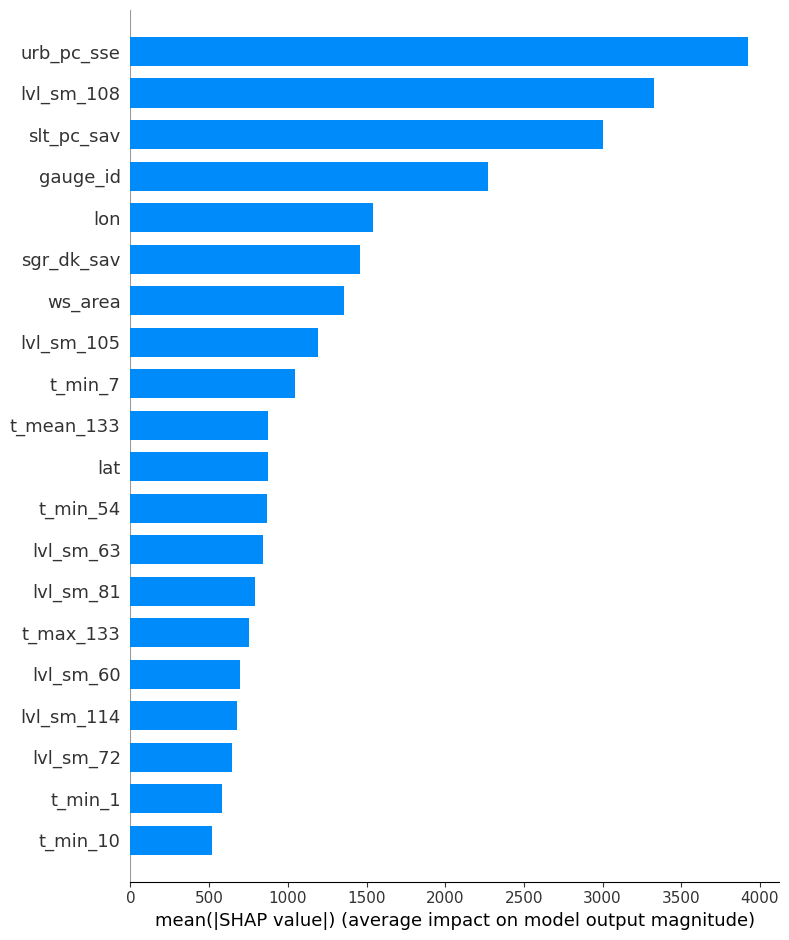

In [15]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

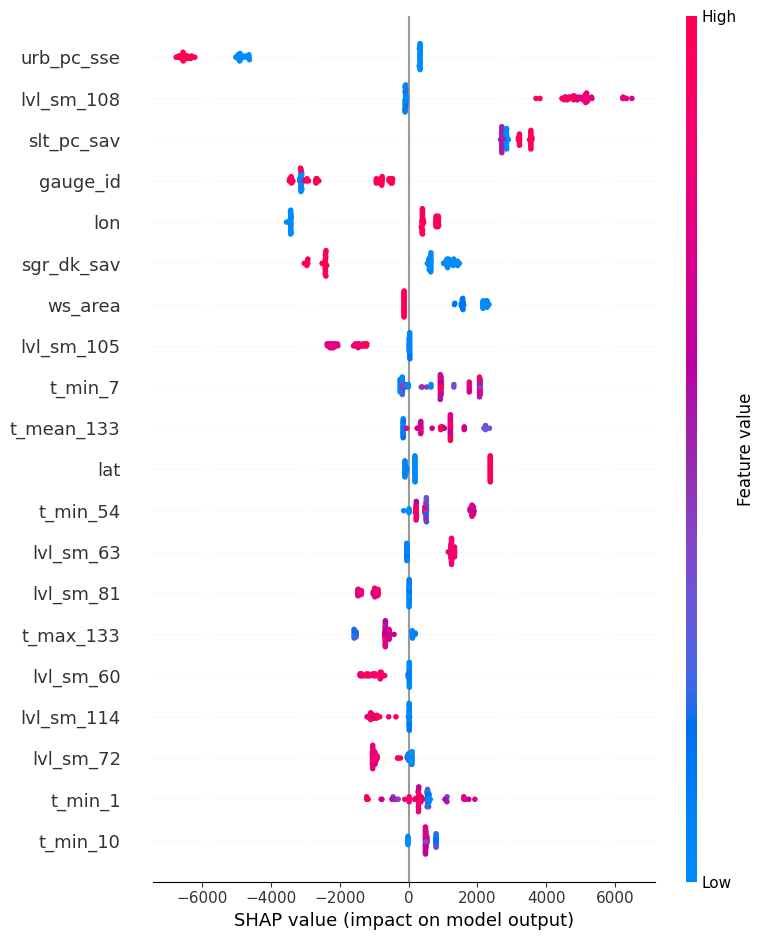

In [16]:
shap.summary_plot(shap_values, X_test)

In [17]:
import gc

client.close()
cluster.close()
gc.collect()

NameError: name 'client' is not defined